In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PANEL_FILE = Path("PanelResults") / "worker_day_panel.csv"
OUTPUT_DIR = Path("MainFigures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(PANEL_FILE, encoding="utf-8-sig")
panel["Date"] = pd.to_datetime(panel["Date"], errors="coerce")

heat_data = panel.loc[
    panel["Location"].eq("Shanghai"),
    ["worker_id", "Date", "WorkerClass", "RestRatio", "weighted_WBGT", "CoreTempRise"],
].copy()
heat_data = heat_data.rename(
    columns={
        "WorkerClass": "Group",
        "CoreTempRise": "core_temp_excursion",
    }
)
heat_data["weighted_WBGT"] = pd.to_numeric(heat_data["weighted_WBGT"], errors="coerce")
heat_data["RestRatio"] = pd.to_numeric(heat_data["RestRatio"], errors="coerce")
heat_data["core_temp_excursion"] = pd.to_numeric(heat_data["core_temp_excursion"], errors="coerce")
heat_data = heat_data.dropna(subset=["weighted_WBGT", "core_temp_excursion", "RestRatio", "Group"])
REST_RATIO_LIMIT = 0.25
heat_data = heat_data[heat_data["RestRatio"] < REST_RATIO_LIMIT].copy()
heat_data = heat_data[heat_data["core_temp_excursion"] > 0.1].copy()

EliteGroup_daily = heat_data[heat_data["Group"].eq("Elite")].copy()
RegularGroup_daily = heat_data[heat_data["Group"].eq("Regular")].copy()

# Heat exposure risk vs weighted WBGT

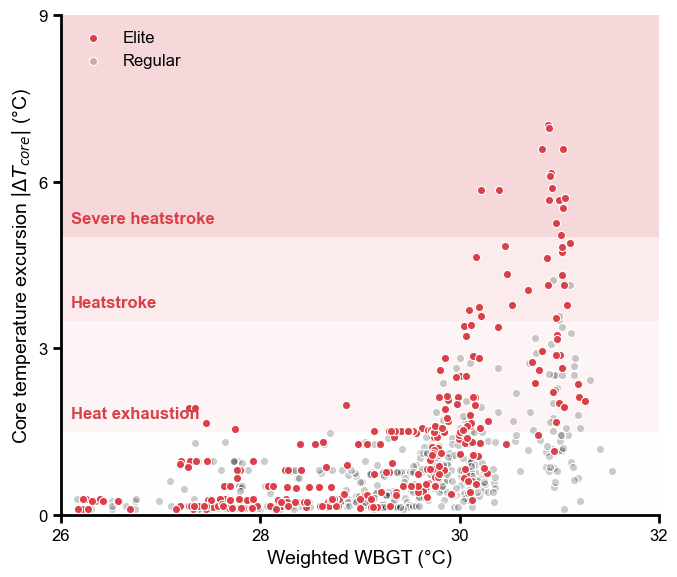

In [2]:
# Global journal-style settings
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'lines.solid_capstyle': 'round',
})


def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i + 2], 16) / 255 for i in (0, 2, 4)]
    return (r, g, b, alpha)


COLORS = {
    'Elite': hex_to_rgba('#DA4048', alpha=1),
    'Regular': hex_to_rgba('#000000', alpha=0.2),
    'shading_0_1.5': hex_to_rgba('#fdfefe'),
    'shading_1.5_3.5': hex_to_rgba('#da4048', alpha=0.05),
    'shading_3.5_5': hex_to_rgba('#da4048', alpha=0.1),
    'shading_5_10': hex_to_rgba('#da4048', alpha=0.2),
}

df_all = pd.concat([EliteGroup_daily, RegularGroup_daily], ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 6))

ax.axhspan(0, 1.5, facecolor=COLORS['shading_0_1.5'], edgecolor='none', zorder=0)
ax.axhspan(1.5, 3.5, facecolor=COLORS['shading_1.5_3.5'], edgecolor='none', zorder=0)
ax.axhspan(3.5, 5, facecolor=COLORS['shading_3.5_5'], edgecolor='none', zorder=0)
ax.axhspan(5, 10, facecolor=COLORS['shading_5_10'], edgecolor='none', zorder=0)

elite = df_all[df_all['Group'] == 'Elite']
ax.scatter(
    elite['weighted_WBGT'], elite['core_temp_excursion'],
    s=35,
    facecolors=COLORS['Elite'],
    edgecolors='white',
    linewidths=0.8,
    label='Elite',
    zorder=2,
)

regular = df_all[df_all['Group'] == 'Regular']
ax.scatter(
    regular['weighted_WBGT'], regular['core_temp_excursion'],
    s=35,
    facecolors=COLORS['Regular'],
    edgecolors='white',
    linewidths=0.8,
    label='Regular',
    zorder=1,
)

ax.set_xlim(26, 32)
ax.set_xticks(np.arange(26, 33, 2))
ax.set_ylim(0, 9)
ax.set_yticks(np.arange(0, 9.1, 3))

ax.set_xlabel("Weighted WBGT (°C)")
ax.set_ylabel(r'Core temperature excursion $|\Delta T_{\mathit{core}}|$ (°C)')

ax.text(26.1, 1.7, 'Heat exhaustion', color=COLORS['Elite'],
        fontsize=12, va='bottom', ha='left', fontweight='bold')
ax.text(26.1, 3.7, 'Heatstroke', color=COLORS['Elite'],
        fontsize=12, va='bottom', ha='left', fontweight='bold')
ax.text(26.1, 5.2, 'Severe heatstroke', color=COLORS['Elite'],
        fontsize=12, va='bottom', ha='left', fontweight='bold')

ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Fig3a.tiff", format='tiff', dpi=600)
plt.show()